# Predição de Consumo de Energia Elétrica em Smart Campus com LSTM

**Universidade Presbiteriana Mackenzie — Faculdade de Computação e Informática**  
**Disciplina:** Inteligência Artificial — 7ºN CC Noite  
**Professor:** Dr. Ivan Carlos Alcântara de Oliveira

---

## Identificação do Grupo

| Nome | RA |
|---|---|
| Mateus Alonso Varjao | 10417888 |
| Lucas Monteiro Soares | 10417881 |
| Leonardo Magalhães | 10417121 |
| Matheus Chediac Rodrigues | 10417490 |

---

## Síntese do Conteúdo

Este notebook realiza o **pré-processamento**, a **análise exploratória (EDA)** e um **modelo baseline** para o dataset de consumo de energia elétrica horário do Edifício A de um campus universitário em Valladolid (Espanha), cobrindo o período de janeiro de 2016 a dezembro de 2020.

**Pipeline:**
1. Carregamento e inspeção dos dados brutos
2. Identificação e tratamento de problemas (ausentes, duplicatas, gaps, erros de medição)
3. Criação de features temporais e cíclicas
4. Análise exploratória visual
5. Modelo baseline (Naive Sazonal) com métricas RMSE, MAE, MAPE e R²

 **Nota:** As seções de pré-processamento (limpeza, tratamento de ausentes, criação de features temporais) e o modelo baseline foram parcialmente aproveitados e adaptados de um notebook desenvolvido anteriormente no contexto do TCC dos integrantes do grupo, que aborda o mesmo tema e dataset. Por esse motivo, o notebook pode conter seções mais avançadas do que o escopo mínimo exigido para a entrega da N1.

---

## Histórico de Alterações

| Data | Autor | Descrição |
|---|---|---|
| 2026-03-10 | Matheus Chediac e Leonardo Magalhães| Criação inicial do notebook de limpeza no contexto do TCC |
| 2026-03-14 | Lucas Monteiro Soares | Adição do tratamento de duplicatas de horário de verão e gaps temporais |
| 2026-03-18 | Leonardo Magalhães | Adição da criação de features temporais lineares e encoding cíclico (sin/cos) |
| 2026-03-22 | Mateus Alonso Varjao | Adição da análise exploratória visual (perfis de consumo, heatmap, correlação) |
| 2026-03-28 | Matheus Chediac Rodrigues | Adaptação do notebook para a disciplina de IA e adição do modelo baseline Naive Sazonal |
| 2026-03-31 | Lucas Monteiro Soares | Revisão geral, padronização do cabeçalho e exportação dos gráficos |

---
# 1. Instalação e Importação de Bibliotecas

In [ ]:
%pip install pandas numpy matplotlib seaborn scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Configurações padrão dos gráficos
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


---
# 2. Descrição do Dataset

O dataset utilizado é proveniente do estudo de Mariano-Hernández et al. (2021) e está disponível publicamente no repositório Mendeley Data (DOI: 10.17632/mzkyh37mtr.2).
  
Contém leituras **horárias** de consumo de energia elétrica (kWh) e variáveis climáticas de um edificio voltado para escritórios administrativos de um campus universitário em Valladolid, Espanha, cobrindo **janeiro de 2016 a dezembro de 2020**.

Neste notebook utilizamos o **Edifício A** (`db_building_A.csv`).

### Dicionário de Variáveis

| Coluna | Descrição | Unidade |
|---|---|---|
| DATE | Timestamp horário | — |
| **ENERGY** | Consumo de energia elétrica **(variável alvo)** | kWh |
| HDD18_3 | Graus-dia de aquecimento (base 18,3°C) | °C·dia |
| CDD0 | Graus-dia de resfriamento (base 0°C) | °C·dia |
| CDD10 | Graus-dia de resfriamento (base 10°C) | °C·dia |
| PRECTOT | Precipitação total | mm/dia |
| RH2M | Umidade relativa a 2m | % |
| T2M | Temperatura média a 2m | °C |
| T2M_MIN | Temperatura mínima a 2m | °C |
| T2M_MAX | Temperatura máxima a 2m | °C |
| ALLSKY | Irradiância solar de céu aberto | MJ/m²/dia |
| HOLIDAY | Indicador de feriado/recesso | 0 ou 1 |

---
# 3. Carregamento e Inspeção Inicial

In [ ]:
df_raw = pd.read_csv('db_building_A.csv', parse_dates=['DATE'])

print(f'Registros carregados : {len(df_raw):,}')
print(f'Colunas              : {list(df_raw.columns)}')
print(f'Período              : {df_raw["DATE"].min()} → {df_raw["DATE"].max()}')
print(f'Horas esperadas (5 anos): {5 * 365 * 24 + 24:,}  (inclui ano bissexto 2016 e 2020)')
df_raw.head()

Registros carregados : 43,848
Colunas              : ['DATE', 'ENERGY', 'HDD18_3', 'CDD0', 'CDD10', 'PRECTOT', 'RH2M', 'T2M', 'T2M_MIN', 'T2M_MAX', 'ALLSKY', 'HOLIDAY']
Período              : 2016-01-01 00:00:00 → 2020-12-31 23:00:00
Horas esperadas (5 anos): 43,824  (inclui ano bissexto 2016 e 2020)


,DATE,ENERGY,HDD18_3,CDD0,CDD10,PRECTOT,RH2M,T2M,T2M_MIN,T2M_MAX,ALLSKY,HOLIDAY
0,2016-01-01 00:00:00,NaN,11.32,6.98,0.0,10.7,90.97,6.02,1.74,12.23,1.7,1
1,2016-01-01 01:00:00,113.415,11.32,6.98,0.0,10.7,90.97,6.02,1.74,12.23,1.7,1
2,2016-01-01 02:00:00,112.431,11.32,6.98,0.0,10.7,90.97,6.02,1.74,12.23,1.7,1
3,2016-01-01 03:00:00,111.517,11.32,6.98,0.0,10.7,90.97,6.02,1.74,12.23,1.7,1
4,2016-01-01 04:00:00,117.240,11.32,6.98,0.0,10.7,90.97,6.02,1.74,12.23,1.7,1


In [ ]:
# Estatísticas descritivas
df_raw.describe().round(2)

,DATE,ENERGY,HDD18_3,CDD0,CDD10,PRECTOT,RH2M,T2M,T2M_MIN,T2M_MAX,ALLSKY,HOLIDAY
count,43848,43746.00,43848.00,43848.00,43848.00,43848.00,43848.00,43848.00,43848.00,43848.00,43704.00,43848.00
mean,2018-07-02 11:58:02.758620672,165.58,6.37,13.01,4.60,1.37,65.74,12.51,6.86,19.16,4.56,0.40
min,2016-01-01 00:00:00,47.93,0.00,0.00,0.00,0.00,24.09,-2.62,-5.86,2.76,0.27,0.00
25%,2017-04-01 17:45:00,117.62,0.00,7.04,0.00,0.00,51.65,6.39,2.20,12.03,2.37,0.00
50%,2018-07-02 12:30:00,131.88,6.19,12.11,2.11,0.08,65.89,11.71,6.43,18.17,4.45,0.00
75%,2019-10-02 06:15:00,202.50,11.26,19.04,9.04,1.28,80.89,18.67,11.68,26.27,6.73,1.00
max,2020-12-31 23:00:00,469.76,19.69,29.01,19.01,46.17,100.00,28.63,20.96,38.66,8.67,1.00
std,NaN,72.33,5.54,7.00,5.30,3.07,17.28,7.26,5.88,8.47,2.35,0.49


---
# 4. Identificação de Problemas nos Dados

In [ ]:
# 4.1 Valores ausentes
print('=== VALORES AUSENTES POR COLUNA ===')
ausentes = df_raw.isnull().sum()
ausentes_pct = (ausentes / len(df_raw) * 100).round(3)
resumo = pd.DataFrame({'Qtd. ausente': ausentes, '% do total': ausentes_pct})
print(resumo[resumo['Qtd. ausente'] > 0])
print('\n→ Menos de 0,5% de ausentes: interpolação temporal é suficiente.')

=== VALORES AUSENTES POR COLUNA ===
        Qtd. ausente  % do total
ENERGY           102       0.233
ALLSKY           144       0.328

→ Menos de 0,5% de ausentes: interpolação temporal é suficiente.


In [ ]:
# 4.2 Timestamps duplicados
duplicados = df_raw[df_raw.duplicated(subset='DATE', keep=False)].sort_values('DATE')
print(f'Timestamps duplicados encontrados: {df_raw["DATE"].duplicated().sum()}')
print()
print(duplicados[['DATE','ENERGY']].to_string(index=False))
print('\n→ Duplicatas ocorrem no retorno do horário de verão europeu (março).')
print('   Ambos os registros são válidos — serão tratados com média.')

Timestamps duplicados encontrados: 4

               DATE  ENERGY
2016-10-30 03:00:00 116.942
2016-10-30 03:00:00 116.265
2018-10-28 03:00:00 123.728
2018-10-28 03:00:00 123.249
2019-10-27 03:00:00 124.069
2019-10-27 03:00:00 125.488
2020-10-25 03:00:00 111.884
2020-10-25 03:00:00 116.356

→ Duplicatas ocorrem no retorno do horário de verão europeu (março).
   Ambos os registros são válidos — serão tratados com média.


In [ ]:
# 4.3 Gaps temporais
df_sorted = df_raw.sort_values('DATE').drop_duplicates(subset='DATE')
diffs = df_sorted['DATE'].diff()
gaps = diffs[diffs > pd.Timedelta('1h')]
print(f'Gaps temporais encontrados (diferença > 1h): {len(gaps)}')
for idx, gap in gaps.items():
    print(f'  {df_sorted.loc[idx, "DATE"]}  →  gap de {gap}')
print('\n→ Gaps de 2h ocorrem na transição para horário de verão (relógios avançam 1h).')
print('   Serão preenchidos via reindex + interpolação.')

Gaps temporais encontrados (diferença > 1h): 4
  2016-03-27 04:00:00  →  gap de 0 days 02:00:00
  2018-03-25 04:00:00  →  gap de 0 days 02:00:00
  2019-03-31 04:00:00  →  gap de 0 days 02:00:00
  2020-03-29 04:00:00  →  gap de 0 days 02:00:00

→ Gaps de 2h ocorrem na transição para horário de verão (relógios avançam 1h).
   Serão preenchidos via reindex + interpolação.


In [ ]:
# 4.4 Erros de medição (ENERGY abaixo do consumo base)
suspeitos = df_raw[df_raw['ENERGY'] < 50]
print(f'Registros com ENERGY < 50 kWh: {len(suspeitos)}')
print()
print(suspeitos[['DATE', 'ENERGY']].to_string(index=False))
print('\n→ Valores abaixo de 50 kWh são inconsistentes com o consumo base do edifício.')
print('   Serão substituídos por NaN e interpolados.')

Registros com ENERGY < 50 kWh: 6

               DATE  ENERGY
2020-05-04 00:00:00  49.154
2020-05-04 01:00:00  47.933
2020-05-04 02:00:00  49.036
2020-05-04 03:00:00  48.307
2020-05-04 04:00:00  49.128
2020-05-04 05:00:00  49.961

→ Valores abaixo de 50 kWh são inconsistentes com o consumo base do edifício.
   Serão substituídos por NaN e interpolados.


---
# 5. Tratamento dos Dados

In [ ]:
# 5.1 Resolver duplicatas de horário de verão (média dos dois registros)
df = df_raw.groupby('DATE').mean().reset_index()
df = df.sort_values('DATE').set_index('DATE')
print(f'Registros antes : {len(df_raw):,}')
print(f'Registros depois: {len(df):,}  (duplicatas resolvidas por média)')

Registros antes : 43,848
Registros depois: 43,844  (duplicatas resolvidas por média)


In [ ]:
# 5.2 Garantir série horária completa (preencher gaps com NaN)
idx_completo = pd.date_range(start='2016-01-01 00:00', end='2020-12-31 23:00', freq='h')
df = df.reindex(idx_completo)
df.index.name = 'DATE'
print(f'Total de registros após reindex: {len(df):,}')
print(f'Ausentes após reindex: {df.isnull().sum().sum()}')

Total de registros após reindex: 43,848
Ausentes após reindex: 290


In [ ]:
# 5.3 Interpolação temporal para variáveis contínuas
colunas_continuas = ['ENERGY', 'ALLSKY', 'T2M', 'T2M_MIN', 'T2M_MAX', 'RH2M', 'PRECTOT']
for col in colunas_continuas:
    antes = df[col].isnull().sum()
    df[col] = df[col].interpolate(method='time')
    depois = df[col].isnull().sum()
    print(f'{col:10s}: {antes:3d} ausentes → {depois} ausentes')

# Variáveis diárias (HDD, CDD, HOLIDAY): preencher com forward fill
colunas_diarias = ['HDD18_3', 'CDD0', 'CDD10', 'HOLIDAY']
df[colunas_diarias] = df[colunas_diarias].ffill()
print(f'\nVariáveis diárias preenchidas com ffill.')

ENERGY    : 106 ausentes → 1 ausentes
ALLSKY    : 148 ausentes → 0 ausentes
T2M       :   4 ausentes → 0 ausentes
T2M_MIN   :   4 ausentes → 0 ausentes
T2M_MAX   :   4 ausentes → 0 ausentes
RH2M      :   4 ausentes → 0 ausentes
PRECTOT   :   4 ausentes → 0 ausentes

Variáveis diárias preenchidas com ffill.


In [ ]:
# 5.4 Corrigir erros de medição em ENERGY
erros = df['ENERGY'] < 50
print(f'Registros com ENERGY < 50 kWh: {erros.sum()}')
df.loc[erros, 'ENERGY'] = np.nan
df['ENERGY'] = df['ENERGY'].interpolate(method='time').bfill()
print(f'Ausentes em ENERGY após correção: {df["ENERGY"].isnull().sum()}')

Registros com ENERGY < 50 kWh: 6
Ausentes em ENERGY após correção: 0


In [ ]:
# 5.5 Verificação final
print(f'Total de registros   : {len(df):,}')
print(f'Período              : {df.index.min()} → {df.index.max()}')
print(f'Total de ausentes    : {df.isnull().sum().sum()}')
print(f'ENERGY — mín: {df["ENERGY"].min():.2f}  máx: {df["ENERGY"].max():.2f}  média: {df["ENERGY"].mean():.2f} kWh')
print()
print('✓ Dataset limpo e sem valores ausentes.')

Total de registros   : 43,848
Período              : 2016-01-01 00:00:00 → 2020-12-31 23:00:00
Total de ausentes    : 0
ENERGY — mín: 51.33  máx: 469.76  média: 165.45 kWh

✓ Dataset limpo e sem valores ausentes.


---
# 6. Criação de Features Temporais

In [ ]:
# Features temporais lineares
df['hour']        = df.index.hour
df['day_of_week'] = df.index.dayofweek   # 0=segunda, 6=domingo
df['month']       = df.index.month
df['is_weekend']  = (df.index.dayofweek >= 5).astype(int)

# Encoding cíclico (sin/cos) — preserva a natureza circular das variáveis
df['hour_sin']        = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos']        = np.cos(2 * np.pi * df['hour'] / 24)
df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['month_sin']       = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']       = np.cos(2 * np.pi * df['month'] / 12)

print('Features temporais criadas.')
print(f'Total de colunas: {len(df.columns)}')
print(list(df.columns))

Features temporais criadas.
Total de colunas: 21
['ENERGY', 'HDD18_3', 'CDD0', 'CDD10', 'PRECTOT', 'RH2M', 'T2M', 'T2M_MIN', 'T2M_MAX', 'ALLSKY', 'HOLIDAY', 'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos']


In [ ]:
# Exportar dataset limpo com features
df.reset_index().to_csv('db_building_A_clean.csv', index=False)
print('Dataset exportado: db_building_A_clean.csv')

Dataset exportado: db_building_A_clean.csv


---
# 7. Análise Exploratória de Dados (EDA)

## 7.1 Série Temporal Completa

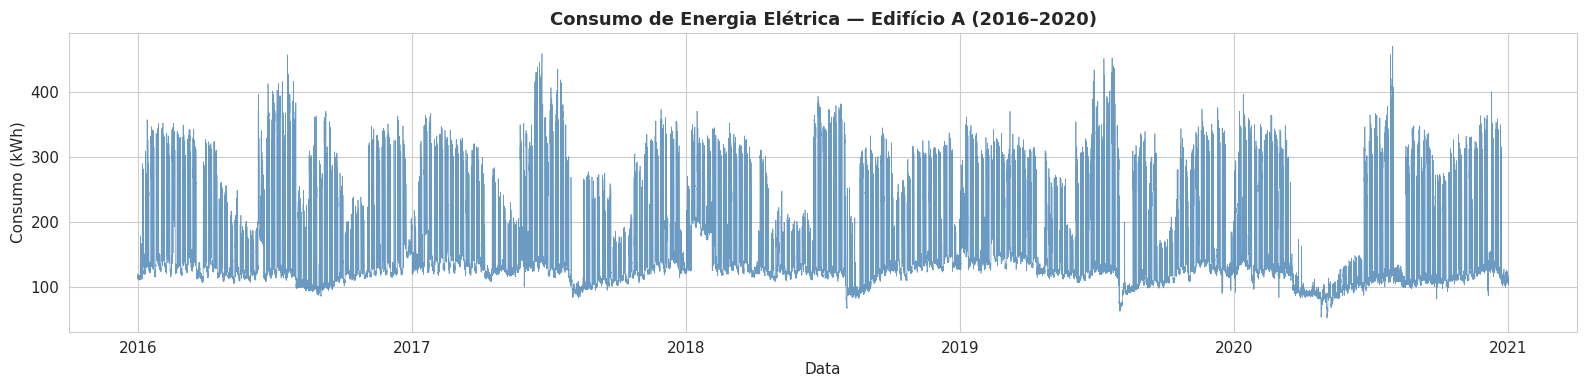

→ Série exportada: fig_serie_temporal.png


In [ ]:
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df.index, df['ENERGY'], linewidth=0.5, color='steelblue', alpha=0.8)
ax.set_title('Consumo de Energia Elétrica — Edifício A (2016–2020)', fontsize=13, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Consumo (kWh)')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('fig_serie_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ Série exportada: fig_serie_temporal.png')

## 7.2 Perfil de Consumo por Hora do Dia

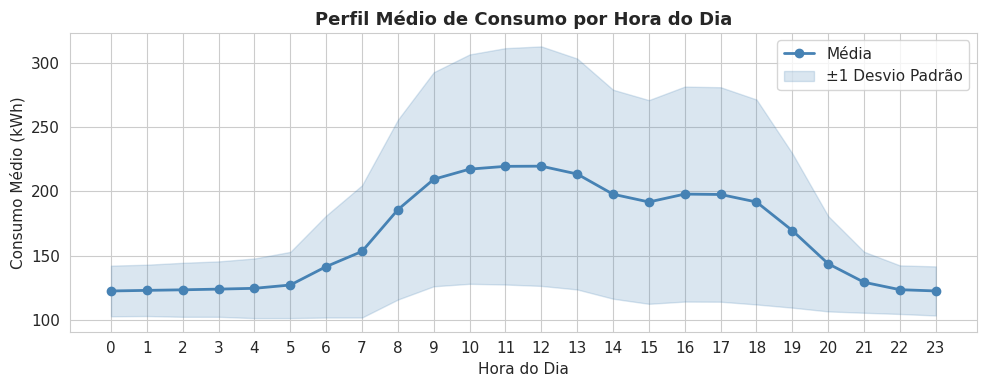

→ Figura exportada: fig_perfil_hora.png


In [ ]:
perfil_hora = df.groupby('hour')['ENERGY'].agg(['mean', 'std'])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(perfil_hora.index, perfil_hora['mean'], marker='o', color='steelblue', linewidth=2, label='Média')
ax.fill_between(perfil_hora.index,
                perfil_hora['mean'] - perfil_hora['std'],
                perfil_hora['mean'] + perfil_hora['std'],
                alpha=0.2, color='steelblue', label='±1 Desvio Padrão')
ax.set_title('Perfil Médio de Consumo por Hora do Dia', fontsize=13, fontweight='bold')
ax.set_xlabel('Hora do Dia')
ax.set_ylabel('Consumo Médio (kWh)')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.savefig('fig_perfil_hora.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ Figura exportada: fig_perfil_hora.png')

## 7.3 Consumo Médio por Dia da Semana

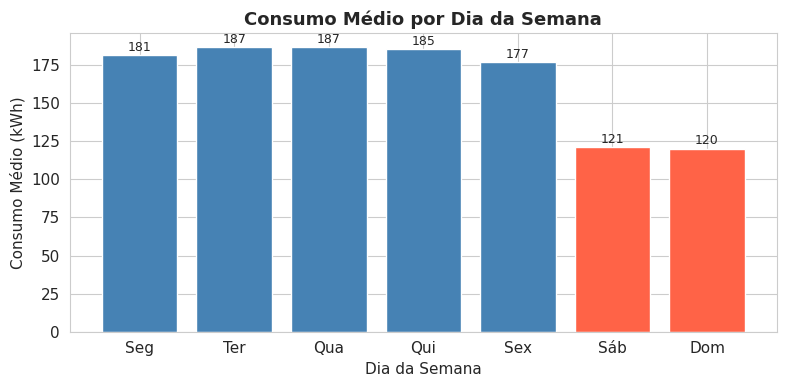

→ Figura exportada: fig_perfil_dia_semana.png


In [ ]:
dias_semana = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
perfil_dia = df.groupby('day_of_week')['ENERGY'].mean()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(dias_semana, perfil_dia.values,
              color=['steelblue']*5 + ['tomato']*2, edgecolor='white')
ax.set_title('Consumo Médio por Dia da Semana', fontsize=13, fontweight='bold')
ax.set_xlabel('Dia da Semana')
ax.set_ylabel('Consumo Médio (kWh)')
for bar, val in zip(bars, perfil_dia.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('fig_perfil_dia_semana.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ Figura exportada: fig_perfil_dia_semana.png')

## 7.4 Heatmap: Hora × Dia da Semana

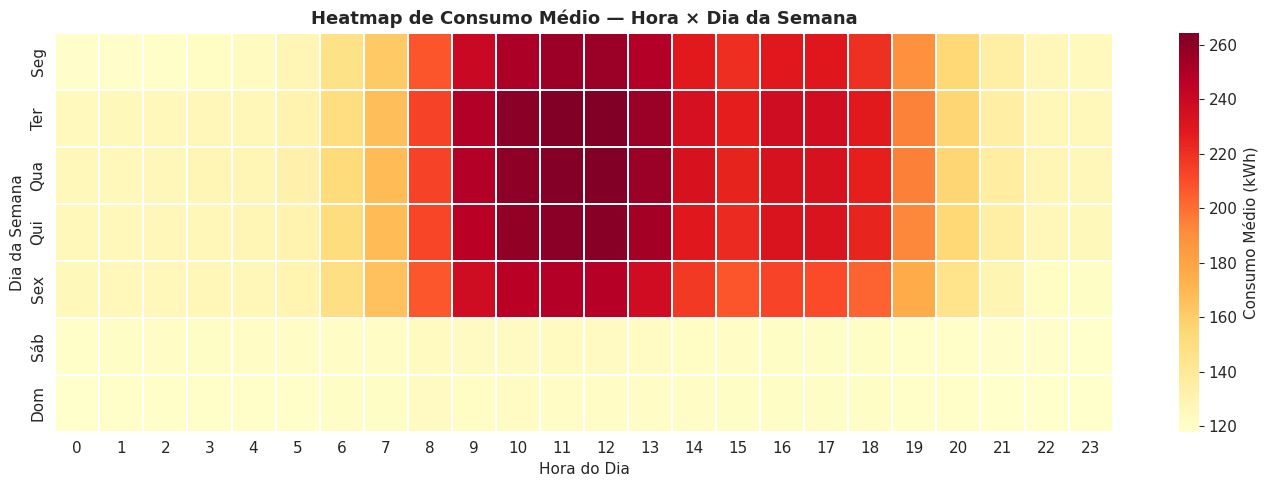

→ Figura exportada: fig_heatmap_hora_dia.png


In [ ]:
heatmap_data = df.groupby(['day_of_week', 'hour'])['ENERGY'].mean().unstack()
heatmap_data.index = dias_semana

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Consumo Médio (kWh)'})
ax.set_title('Heatmap de Consumo Médio — Hora × Dia da Semana', fontsize=13, fontweight='bold')
ax.set_xlabel('Hora do Dia')
ax.set_ylabel('Dia da Semana')
plt.tight_layout()
plt.savefig('fig_heatmap_hora_dia.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ Figura exportada: fig_heatmap_hora_dia.png')

## 7.5 Consumo Médio por Mês (Sazonalidade Anual)

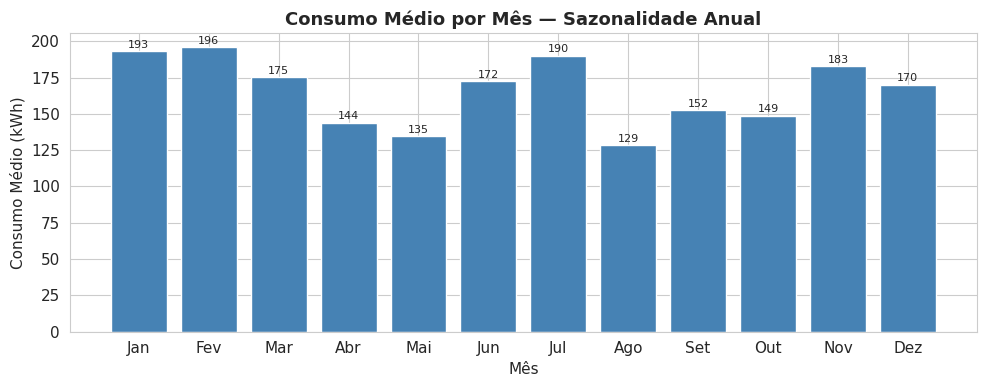

→ Figura exportada: fig_perfil_mensal.png


In [ ]:
meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
perfil_mes = df.groupby('month')['ENERGY'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(meses, perfil_mes.values, color='steelblue', edgecolor='white')
ax.set_title('Consumo Médio por Mês — Sazonalidade Anual', fontsize=13, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Consumo Médio (kWh)')
for i, val in enumerate(perfil_mes.values):
    ax.text(i, val + 1, f'{val:.0f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('fig_perfil_mensal.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ Figura exportada: fig_perfil_mensal.png')

## 7.6 Correlação entre Variáveis

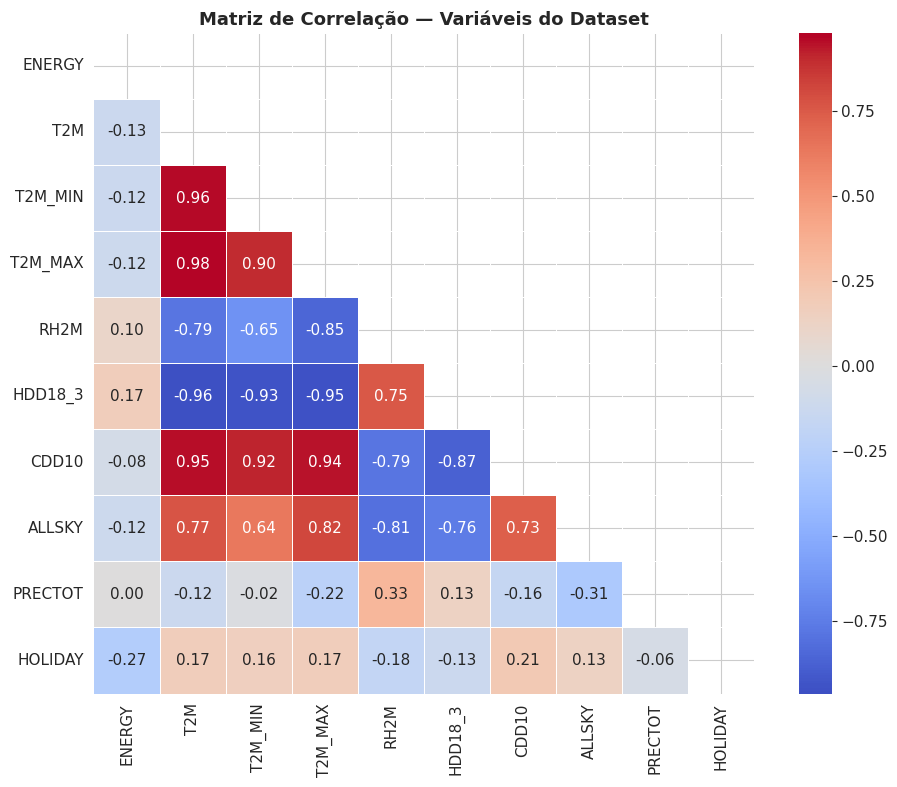

→ Figura exportada: fig_correlacao.png


In [ ]:
cols_corr = ['ENERGY', 'T2M', 'T2M_MIN', 'T2M_MAX', 'RH2M', 'HDD18_3', 'CDD10', 'ALLSKY', 'PRECTOT', 'HOLIDAY']
corr_matrix = df[cols_corr].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, ax=ax, linewidths=0.5, square=True)
ax.set_title('Matriz de Correlação — Variáveis do Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ Figura exportada: fig_correlacao.png')

## 7.7 Distribuição do Consumo (Dias Úteis vs. Fins de Semana)

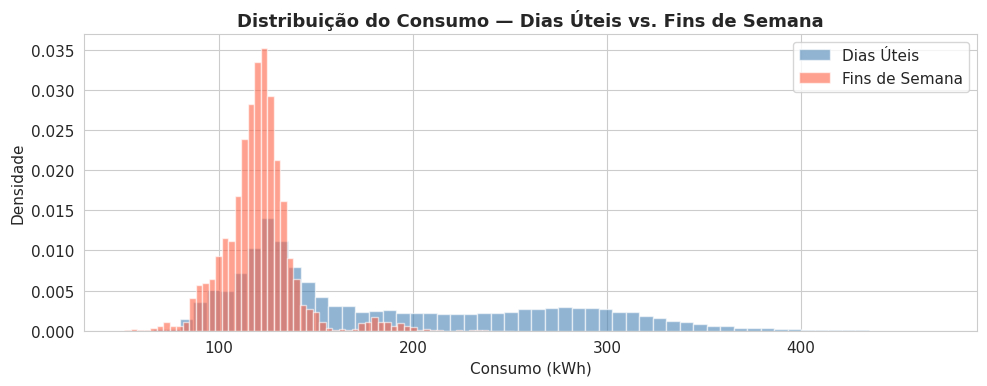

→ Figura exportada: fig_distribuicao_semana.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
df[df['is_weekend'] == 0]['ENERGY'].plot.hist(bins=60, alpha=0.6, color='steelblue',
                                               label='Dias Úteis', ax=ax, density=True)
df[df['is_weekend'] == 1]['ENERGY'].plot.hist(bins=60, alpha=0.6, color='tomato',
                                               label='Fins de Semana', ax=ax, density=True)
ax.set_title('Distribuição do Consumo — Dias Úteis vs. Fins de Semana', fontsize=13, fontweight='bold')
ax.set_xlabel('Consumo (kWh)')
ax.set_ylabel('Densidade')
ax.legend()
plt.tight_layout()
plt.savefig('fig_distribuicao_semana.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ Figura exportada: fig_distribuicao_semana.png')

---
# 8. Modelo Baseline — Naive Sazonal (24h)

O **Naive Sazonal** usa como previsão o valor observado exatamente 24 horas antes.  
É o baseline mais simples e adequado para séries com padrão diário, servindo como referência mínima que o modelo LSTM deverá superar.

**Divisão temporal:**
- Treino: 2016–2019 (4 anos)
- Teste: 2020 (1 ano)

In [ ]:
# Divisão treino/teste
train = df[df.index.year < 2020]['ENERGY']
test  = df[df.index.year == 2020]['ENERGY']

print(f'Treino: {len(train):,} registros ({train.index.min().date()} → {train.index.max().date()})')
print(f'Teste : {len(test):,} registros ({test.index.min().date()} → {test.index.max().date()})')

Treino: 35,064 registros (2016-01-01 → 2019-12-31)
Teste : 8,784 registros (2020-01-01 → 2020-12-31)


In [ ]:
# Naive Sazonal: previsão = valor de 24h atrás
energy_series = df['ENERGY']
naive_pred = energy_series.shift(24)
naive_test = naive_pred[df.index.year == 2020]

# Remover NaN (primeiras 24h)
valid_idx = test.index.intersection(naive_test.dropna().index)
y_true = test[valid_idx].values
y_pred = naive_test[valid_idx].values

# Métricas
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2   = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)

print('=== RESULTADOS — BASELINE NAIVE SAZONAL (24h) ===')
print(f'RMSE : {rmse:.2f} kWh')
print(f'MAE  : {mae:.2f} kWh')
print(f'MAPE : {mape:.2f} %')
print(f'R²   : {r2:.4f}')
print()
print('→ Esses resultados servem como referência mínima para o modelo LSTM.')

=== RESULTADOS — BASELINE NAIVE SAZONAL (24h) ===
RMSE : 54.38 kWh
MAE  : 25.28 kWh
MAPE : 15.62 %
R²   : 0.4981

→ Esses resultados servem como referência mínima para o modelo LSTM.


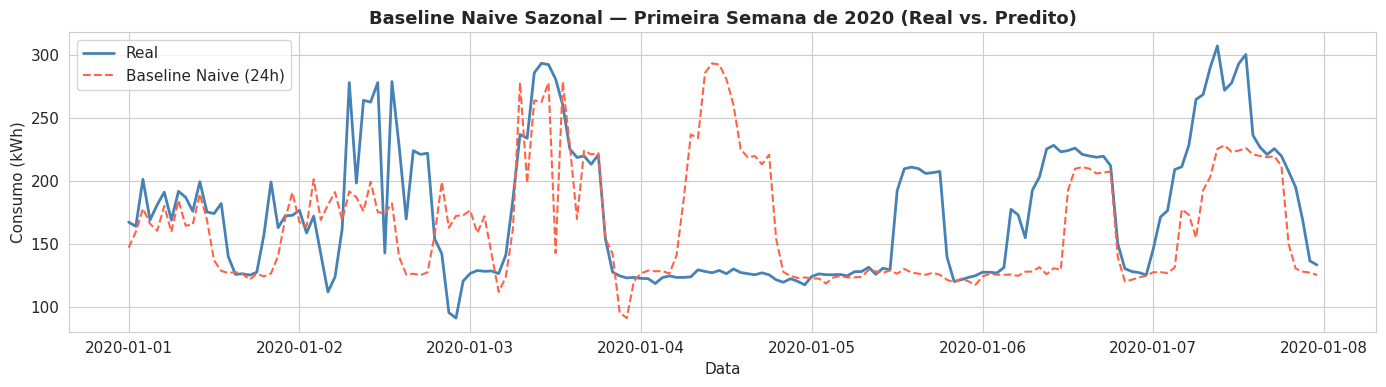

→ Figura exportada: fig_baseline_semana.png


In [ ]:
# Visualização: Real vs. Baseline — primeira semana de teste
semana = valid_idx[:24*7]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(semana, y_true[:24*7], label='Real', color='steelblue', linewidth=2)
ax.plot(semana, y_pred[:24*7], label='Baseline Naive (24h)', color='tomato',
        linewidth=1.5, linestyle='--')
ax.set_title('Baseline Naive Sazonal — Primeira Semana de 2020 (Real vs. Predito)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Consumo (kWh)')
ax.legend()
plt.tight_layout()
plt.savefig('fig_baseline_semana.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ Figura exportada: fig_baseline_semana.png')

In [ ]:
# Tabela resumo de métricas
resultados = pd.DataFrame({
    'Modelo': ['Naive Sazonal (24h)', 'LSTM (a implementar)'],
    'RMSE (kWh)': [f'{rmse:.2f}', '—'],
    'MAE (kWh)':  [f'{mae:.2f}',  '—'],
    'MAPE (%)':   [f'{mape:.2f}', '—'],
    'R²':         [f'{r2:.4f}',   '—'],
})
print(resultados.to_string(index=False))

              Modelo RMSE (kWh) MAE (kWh) MAPE (%)     R²
 Naive Sazonal (24h)      54.38     25.28    15.62 0.4981
LSTM (a implementar)          —         —        —      —


---
# 9. Resumo dos Resultados Parciais

## Principais achados da EDA

- **Padrão diário claro:** o consumo sobe a partir das 7h, atinge pico entre 10h–14h e cai à noite.
- **Queda nos fins de semana:** consumo médio de sábado e domingo é consideravelmente menor que dias úteis, refletindo menor ocupação do campus.
- **Sazonalidade anual:** consumo mais elevado nos meses de inverno (jan, fev, dez) e verão (jul, ago), relacionado ao uso de sistemas de climatização.
- **Correlações relevantes:** temperatura (T2M) e graus-dia (HDD, CDD) apresentam correlação moderada com o consumo, confirmando a influência do clima.
- **Dataset limpo:** após tratamento, 0 valores ausentes em 43.848 registros horários.

## Resultado do Baseline

O modelo Naive Sazonal (24h) serve como referência mínima. O modelo LSTM deverá superar essas métricas ao capturar dependências temporais de maior alcance e a influência das variáveis climáticas e de calendário.